### functions

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 · Imports & shared utilities
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
from itertools import combinations as icomb
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import CCA
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


def _parse_groups(metric_groups):
    """Normalise every element to a tuple of metric name strings."""
    return [(g,) if isinstance(g, str) else tuple(g) for g in metric_groups]


def _get(metrics, heads, data):
    """Return float array (N, k) for k metric names across N heads."""
    cols = [np.array([data[h][m] for h in heads], dtype=float) for m in metrics]
    return np.column_stack(cols) if len(cols) > 1 else cols[0].reshape(-1, 1)


def _zs(X):
    """Z-score each column; safe against zero-variance columns."""
    mu, sd = X.mean(0), X.std(0)
    return (X - mu) / np.where(sd == 0, 1.0, sd)


def _sname(m):
    """Compact display name: 'ov_weighted_subspace_overlap' → 'ov_overlap'."""
    p = m.split("_")
    if len(p) <= 2:  return m
    if len(p) == 3:  return "_".join(p[-2:]) # last two parts
    return f"{p[0]}_{p[-1]}"   # first + last part


def _glabel(group):
    return " & ".join(_sname(m) for m in group)

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 · Method 1 — Derived Feature Correlations
#
# KEY IDEA:
#   "A↑ while B↓ → Z↑"  ⟺  r(A−B, Z) is strongly positive
#   "A and B both large → Z↑"  ⟺  r(A+B, Z) is strongly positive
#   "cross-effect matters"  ⟺  r(A×B, Z) is large
#
# For k predictors we build:
#   · k individual z-scored metrics
#   · C(k,2) × 4 pairwise: sum, diff(i−j), diff(j−i), product
# then rank by |r| with every target.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def _build_derived(X_z, metrics):
    """Dict of {name: 1-D array} for all derived features of a z-scored matrix."""
    feats = {_sname(m): X_z[:, i] for i, m in enumerate(metrics)}
    for i, j in icomb(range(len(metrics)), 2):
        a, b = _sname(metrics[i]), _sname(metrics[j])
        feats[f"{a}+{b}"] = X_z[:, i] + X_z[:, j]
        feats[f"{a}−{b}"] = X_z[:, i] - X_z[:, j]   # ← the key contrast
        feats[f"{b}−{a}"] = X_z[:, j] - X_z[:, i]
        feats[f"{a}×{b}"] = X_z[:, i] * X_z[:, j]
    return feats


def plot_derived_correlations(pred_group, tgt_group, heads, data, top_n=6):
    """
    Correlation heatmap of all derived predictor features vs each target.
    Scatter plots are shown for the top-n highest |r| (feature, target) pairs.

    Parameters
    ----------
    pred_group  tuple of str   predictor metrics
    tgt_group   tuple of str   target metrics
    top_n       int            how many scatter plots to display
    
    Returns
    -------
    pd.DataFrame  sorted by |r|; read the top row to find the dominant pattern.
    """
    X_z   = _zs(_get(pred_group, heads, data))      # (N, k_pred)
    feats  = _build_derived(X_z, pred_group)
    fnames = list(feats.keys())
    F      = np.vstack(list(feats.values()))          # (n_feats, N)

    Y_z    = _zs(_get(tgt_group, heads, data))        # (N, n_tgts)
    tlbls  = [_sname(t) for t in tgt_group]
    n_tgts, n_feats = len(tgt_group), len(fnames)

    # ── Pearson r matrix: rows=features, cols=targets ──────
    R = np.array([
        [stats.pearsonr(F[fi], Y_z[:, ti])[0] for ti in range(n_tgts)]
        for fi in range(n_feats)
    ])

    # Top (feature, target) pairs by |r|
    flat_top  = np.argsort(np.abs(R).flatten())[::-1][:top_n]
    top_pairs = [(idx // n_tgts, idx % n_tgts) for idx in flat_top]
    top_fi    = set(fi for fi, _ in top_pairs)

    # Labels: star the top features
    ylbls = [f"★ {n}" if i in top_fi else n for i, n in enumerate(fnames)]

    # ── Figure layout ───────────────────────────────────────
    ncols_s = min(3, top_n)
    nrows_s = (top_n + ncols_s - 1) // ncols_s
    fig = plt.figure(figsize=(4 + 3.5 * ncols_s,
                               max(5, 0.38 * n_feats + 3 * nrows_s * 0.6)))

    w_heat = max(1.0, n_tgts * 0.7 + 0.5)
    gs = gridspec.GridSpec(1, 2, figure=fig,
                           width_ratios=[w_heat, ncols_s], wspace=0.45)

    # ── Heatmap ─────────────────────────────────────────────
    ax_h = fig.add_subplot(gs[0])
    im   = ax_h.imshow(R, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax_h.set_xticks(range(n_tgts));  ax_h.set_xticklabels(tlbls, rotation=35, ha='right', fontsize=8)
    ax_h.set_yticks(range(n_feats)); ax_h.set_yticklabels(ylbls, fontsize=7)
    ax_h.set_title("Derived feature correlations\nwith target(s)", fontsize=9)
    plt.colorbar(im, ax=ax_h, fraction=0.06, pad=0.03, label="Pearson r")

    for fi in range(n_feats):
        for ti in range(n_tgts):
            r_val = R[fi, ti]
            ax_h.text(ti, fi, f"{r_val:.2f}", ha='center', va='center',
                      fontsize=6, color='white' if abs(r_val) > 0.55 else 'black')

    # ── Scatter plots for top pairs ──────────────────────────
    gs_s = gridspec.GridSpecFromSubplotSpec(nrows_s, ncols_s,
                                            subplot_spec=gs[1], hspace=0.7, wspace=0.4)
    for idx, (fi, ti) in enumerate(top_pairs):
        row, col = divmod(idx, ncols_s)
        ax  = fig.add_subplot(gs_s[row, col])
        x, y = F[fi], Y_z[:, ti]
        ax.scatter(x, y, s=14, alpha=0.55, color='steelblue', linewidths=0)
        xl  = np.linspace(x.min(), x.max(), 60)
        ax.plot(xl, np.polyval(np.polyfit(x, y, 1), xl), lw=1.5, color='tomato', alpha=0.85)
        ax.set_title(f"{fnames[fi]}  →  {tlbls[ti]}\nr = {R[fi, ti]:.3f}", fontsize=7)
        ax.tick_params(labelsize=5)

    fig.suptitle(
        f"Pattern: ({_glabel(pred_group)})  →  ({_glabel(tgt_group)})",
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # Return tidy summary sorted by |r|
    rows = [{"feature": fnames[fi], "target": tlbls[ti], "r": round(R[fi, ti], 4)}
            for fi in range(n_feats) for ti in range(n_tgts)]
    return pd.DataFrame(rows).sort_values("r", key=abs, ascending=False).reset_index(drop=True)

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 · Method 2 — Multiple Regression + Interaction Terms
#
# Fits:  Z = β₁A + β₂B + β₃(A×B)  (all z-scored)
# A significant β₃ for A×B means the joint behaviour matters
# above and beyond each metric individually.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_regression_group(pred_group, tgt_group, heads, data, interactions=True):
    """
    Regress each target on the full predictor group + pairwise interaction terms.
    Shows standardised coefficients and R² / adj-R².
    Only call when pred_group has ≥ 2 metrics (otherwise it's just Pearson r).
    """
    X_raw   = _zs(_get(pred_group, heads, data))        # (N, k)
    fnames  = [_sname(m) for m in pred_group]
    X       = X_raw.copy()

    if interactions and len(pred_group) > 1:
        for i, j in icomb(range(len(pred_group)), 2):
            X = np.column_stack([X, X_raw[:, i] * X_raw[:, j]])
            fnames.append(f"{_sname(pred_group[i])}×{_sname(pred_group[j])}")

    n_tgts = len(tgt_group)
    fig, axes = plt.subplots(1, n_tgts, figsize=(4.5 * n_tgts, 2.5 + 0.45 * len(fnames)),
                             squeeze=False)

    for ci, target in enumerate(tgt_group):
        y   = _zs(_get((target,), heads, data))[:, 0]
        reg = LinearRegression().fit(X, y)
        yh  = reg.predict(X)
        N, p = len(y), X.shape[1]
        r2   = 1 - np.sum((y - yh) ** 2) / np.sum((y - y.mean()) ** 2)
        r2a  = 1 - (1 - r2) * (N - 1) / (N - p - 1)

        ax   = axes[0, ci]
        cols = ['#4d9de0' if c >= 0 else '#e15554' for c in reg.coef_]
        bars = ax.barh(fnames, reg.coef_, color=cols, height=0.6, edgecolor='white', lw=0.5)
        ax.axvline(0, color='#555', lw=0.9, ls='--', alpha=0.6)

        for bar, coef in zip(bars, reg.coef_):
            pad = 0.015 if coef >= 0 else -0.015
            ax.text(coef + pad, bar.get_y() + bar.get_height() / 2,
                    f"{coef:+.2f}", va='center',
                    ha='left' if coef >= 0 else 'right', fontsize=7.5)

        ax.set_xlabel("Std. coefficient", fontsize=8)
        ax.set_title(f"→ {_sname(target)}\nR² = {r2:.3f}   adj-R² = {r2a:.3f}", fontsize=9)

    fig.suptitle(
        f"Regression  ({_glabel(pred_group)})  →  ({_glabel(tgt_group)})\n"
        f"Blue = positive effect  ·  Red = negative effect", fontsize=9
    )
    plt.tight_layout()
    plt.show()

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 · Method 3 — Canonical Correlation Analysis (CCA)
#
# Only meaningful when BOTH groups have ≥ 2 metrics.
# Finds the linear combo of Group A and the linear combo of Group B
# that are maximally correlated — i.e. the "shared structure".
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_cca(group_a, group_b, heads, data):
    """
    CCA between two multi-metric groups. Auto-skips for single-metric groups.
    Displays loadings (which metrics drive each canonical variate) and the
    canonical variate scatter plot.
    """
    if len(group_a) < 2 or len(group_b) < 2:
        print(f"  ⚠  CCA requires ≥2 metrics in each group — skipped.\n"
              f"     ({_glabel(group_a)}) has {len(group_a)}, ({_glabel(group_b)}) has {len(group_b)}.")
        return

    X, Y   = _zs(_get(group_a, heads, data)), _zs(_get(group_b, heads, data))
    n_comp = min(len(group_a), len(group_b))
    cca    = CCA(n_components=n_comp)
    Xc, Yc = cca.fit_transform(X, Y)
    cc_rs  = [stats.pearsonr(Xc[:, i], Yc[:, i])[0] for i in range(n_comp)]

    fig, axes = plt.subplots(1, n_comp + 1, figsize=(4.5 * (n_comp + 1), 4))
    axes = np.array(axes).flatten()

    # ── Loadings: which metrics contribute to the first canonical variate ──
    ax0       = axes[0]
    a_load    = cca.x_loadings_[:, 0]
    b_load    = cca.y_loadings_[:, 0]
    names_ab  = [f"A · {_sname(m)}" for m in group_a] + [f"B · {_sname(m)}" for m in group_b]
    loads_ab  = np.concatenate([a_load, b_load])
    color_ab  = ['#4d9de0'] * len(group_a) + ['#e15554'] * len(group_b)

    ax0.barh(names_ab, loads_ab, color=color_ab, height=0.6, edgecolor='white', lw=0.4)
    ax0.axvline(0, color='#555', lw=0.9, ls='--', alpha=0.6)
    ax0.set_title(f"1st canonical loadings\ncanonical r = {cc_rs[0]:.3f}", fontsize=9)
    ax0.legend(handles=[mpatches.Patch(color='#4d9de0', label=f'Group A'),
                         mpatches.Patch(color='#e15554', label=f'Group B')],
               fontsize=7, loc='lower right')

    # ── Canonical variate scatter for each component ───────────────────────
    for ci in range(n_comp):
        ax  = axes[ci + 1]
        xc, yc = Xc[:, ci], Yc[:, ci]
        ax.scatter(xc, yc, s=15, alpha=0.55, color='steelblue', linewidths=0)
        xl = np.linspace(xc.min(), xc.max(), 60)
        ax.plot(xl, np.polyval(np.polyfit(xc, yc, 1), xl), lw=1.5, color='tomato', alpha=0.85)
        ax.set_xlabel(f"Canonical A{ci+1}", fontsize=9)
        ax.set_ylabel(f"Canonical B{ci+1}", fontsize=9)
        ax.set_title(f"Canonical pair {ci+1}\nr = {cc_rs[ci]:.3f}", fontsize=9)

    fig.suptitle(
        f"CCA:  ({_glabel(group_a)})  ↔  ({_glabel(group_b)})\n"
        f"Canonical rs: {[f'{r:.3f}' for r in cc_rs]}",
        fontsize=9
    )
    plt.tight_layout()
    plt.show()

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 · Main wrapper — plot_group_correlations
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_group_correlations(metric_groups, key_indices=None, data=None,
                            methods=("derived", "regression", "cca"), top_n=6):
    """
    Analyse all pairwise (A → B) group relationships.

    Parameters
    ----------
    metric_groups : list of str | tuple of str
        str  = single metric (treated as a 1-metric group)
        tuple = multi-metric group analysed jointly

    key_indices : list of int | None
        Subset of heads by position (same API as original plot_correlations).

    methods : tuple
        Any subset of {"derived", "regression", "cca"}.
        - "derived"    always runs (the main pattern detector)
        - "regression" runs only for predictor groups with ≥ 2 metrics
        - "cca"        runs only when both groups have ≥ 2 metrics

    top_n : int
        Number of scatter plots shown in the derived view.
    """
    if data is None:
        data = all_data
    heads = list(data.keys())
    if key_indices is not None:
        heads = [heads[i] for i in key_indices]

    groups = _parse_groups(metric_groups)

    for i, j in icomb(range(len(groups)), 2):
        A, B = groups[i], groups[j]
        sep  = "━" * 58
        print(f"\n{sep}")
        print(f"  Predictor group : {A}")
        print(f"  Target group    : {B}")
        print(sep)

        if "derived" in methods:
            print("\n── Method 1 · Derived Feature Correlations ──")
            df = plot_derived_correlations(A, B, heads, data, top_n=top_n)
            print(df.head(8).to_string(index=False))

        if "regression" in methods and len(A) > 1:
            print("\n── Method 2 · Multiple Regression (with interactions) ──")
            plot_regression_group(A, B, heads, data)

        if "cca" in methods:
            print("\n── Method 3 · Canonical Correlation Analysis ──")
            plot_cca(A, B, heads, data)

### usage

In [6]:
import json
JSON_PATHS = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_org_clip.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/change_metrics_fft.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/act_change_metrics_fft.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/head_spec_metrics.json",
]

def load_all(paths):
    merged = {}
    for p in paths:
        with open(p) as f:
            data = json.load(f)
        for head, metrics in data.items():
            merged.setdefault(head, {}).update(metrics)
    return merged

all_data = load_all(JSON_PATHS)

def plot_correlations(metric_names, key_indices=None, data=None):
    if data is None:
        data = all_data
    heads = list(data.keys())
    if key_indices is not None:
        heads = [heads[i] for i in key_indices]

    vals = {m: np.array([data[h][m] for h in heads]) for m in metric_names}

    n = len(metric_names)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    if n == 1: axes = [[axes]]

    for i, m1 in enumerate(metric_names):
        for j, m2 in enumerate(metric_names):
            ax = axes[i][j]
            x, y = vals[m2], vals[m1]
            ax.scatter(x, y, alpha=0.6, s=20)
            if i != j:
                r, _ = stats.pearsonr(x, y)
                ax.set_title(f"r = {r:.2f}", fontsize=9)
            if j == 0: ax.set_ylabel(m1, fontsize=8)
            if i == n-1: ax.set_xlabel(m2, fontsize=8)

    plt.tight_layout()
    plt.show()

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 · Usage
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# # ── Drop-in replacement for your existing call ─────────────────────────
# plot_group_correlations(
#     metric_groups=[
#         ("ov_weighted_subspace_overlap", "qk_weighted_subspace_overlap"),
#         "Principal_Angle_Deg",          # str is fine — treated as 1-metric group
#     ],
#     key_indices=list(range(0, 48)),
#     methods=("derived", "regression"),  # CCA auto-skips (Principal_Angle_Deg is 1-metric)
# )

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Q2: Subspace rotation vs energy scaling — which matters for new task?
#
# Core question: heads that become useful for the new task —
# did they ROTATE into new directions, or just RESCALE existing ones?
# If new_direction_fraction correlates with rank_mean but
# weighted_subspace_overlap doesn't, rotation is the mechanism.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# plot_group_correlations(
#     metric_groups=[
#         ("ov_new_direction_fraction", "ov_weighted_subspace_overlap"),
#         ("rank_mean", "top_k_mean"),
#     ],
#     key_indices=list(range(0, 48)),
#     methods=("derived", "regression", "cca"),
# )

### part2

In [9]:
def cross_correlations(predictors, observations, key_indices=None, data=None,
                       plot=False, plot_grid=False, top_n=None):
    """
    Correlate every predictor metric against every observation metric.
    No within-group or self correlations.

    Parameters
    ----------
    predictors   : list of str — specificity / new-task relevance metrics
    observations : list of str — change metrics (weight or representation)
    plot         : bool — show scatter matrix (predictor cols × observation rows)
    plot_grid    : bool — show compact color-coded correlation grid (no scatter)
    top_n        : int|None — if set, only return top N pairs by |r|

    Returns
    -------
    pd.DataFrame with columns: predictor, observation, r, abs_r — sorted by abs_r desc
    """
    if data is None:
        data = all_data
    heads = list(data.keys())
    if key_indices is not None:
        heads = [heads[i] for i in key_indices]

    # skip any metric that accidentally appears in both lists
    observations = [m for m in observations if m not in predictors]

    vals_p = {m: np.array([data[h][m] for h in heads]) for m in predictors}
    vals_o = {m: np.array([data[h][m] for h in heads]) for m in observations}

    # ── compute all cross-correlations ──────────────────────
    rows = []
    for pm in predictors:
        for om in observations:
            r, p = stats.pearsonr(vals_p[pm], vals_o[om])
            rows.append({"predictor": pm, "observation": om,
                         "r": round(r, 4), "p_value": round(p, 5),
                         "abs_r": round(abs(r), 4)})

    df = (pd.DataFrame(rows)
            .sort_values("abs_r", ascending=False)
            .reset_index(drop=True))

    if top_n is not None:
        df = df.head(top_n)

    # ── compact correlation grid: rows=observations, cols=predictors ─
    if plot_grid:
        np_r = len(predictors)
        no_r = len(observations)

        # build r matrix
        r_matrix = np.array([
            [stats.pearsonr(vals_p[pm], vals_o[om])[0] for pm in predictors]
            for om in observations
        ])

        def _cell_color(r_val):
            # if abs(r_val) > 0.5:
            #     return [0xe1/255, 0x55/255, 0x54/255]   # #e15554 red
            # elif abs(r_val) > 0.3:
            #     return [0x4d/255, 0x9d/255, 0xe0/255]   # #4d9de0 blue
            # else:
            #     return [0xaa/255, 0xaa/255, 0xaa/255]   # #aaa gray
            # high neg = dark red, mid neg = light red, mid pos = light blue, high pos = dark blue
            if r_val < -0.5:
                return [0xe1/255, 0x55/255, 0x54/255]   # #e15554 dark red
            elif r_val < -0.3:
                return [0xf4/255, 0xa5/255, 0x82/255]   # #f4a582 light red
            elif r_val > 0.5:
                return [0x4d/255, 0x9d/255, 0xe0/255]   # #4d9de0 dark blue
            elif r_val > 0.3:
                return [0x92/255, 0xc5/255, 0xde/255]   # #92c5de light blue
            else:
                return [0xaa/255, 0xaa/255, 0xaa/255]   # #aaa gray

        color_array = np.array([[_cell_color(r_matrix[i, j])
                                 for j in range(np_r)]
                                for i in range(no_r)])

        cell_w, cell_h = max(1.2, 7 / np_r), max(0.5, 5 / no_r)
        fig, ax = plt.subplots(figsize=(cell_w * np_r + 2, cell_h * no_r + 1.5))
        ax.imshow(color_array, aspect='auto')

        for i in range(no_r):
            for j in range(np_r):
                r_val = r_matrix[i, j]
                text_color = 'white' if abs(r_val) > 0.3 else '#333'
                ax.text(j, i, f"{r_val:.2f}", ha='center', va='center',
                        fontsize=8, color=text_color, fontweight='bold')

        ax.set_xticks(range(np_r))
        ax.set_xticklabels(predictors, rotation=35, ha='right', fontsize=7)
        ax.set_yticks(range(no_r))
        ax.set_yticklabels(observations, fontsize=7)
        ax.set_title("Predictors (cols) → Observations (rows)", fontsize=10)

        from matplotlib.patches import Patch
        legend = [
            Patch(color='#e15554', label='|r| > 0.5'),
            Patch(color='#4d9de0', label='|r| > 0.3'),
            Patch(color='#aaa',    label='|r| ≤ 0.3'),
        ]
        ax.legend(handles=legend, loc='upper left', bbox_to_anchor=(1.01, 1),
                  fontsize=7, frameon=False)

        plt.tight_layout()
        plt.show()

    # ── optional scatter matrix: rows=observations, cols=predictors ─
    if plot:
        np_r = len(predictors)
        no_r = len(observations)
        fig, axes = plt.subplots(no_r, np_r,
                                 figsize=(3 * np_r, 2.5 * no_r),
                                 squeeze=False)

        for i, om in enumerate(observations):
            for j, pm in enumerate(predictors):
                ax = axes[i][j]
                x, y = vals_p[pm], vals_o[om]
                r, _ = stats.pearsonr(x, y)

                # color = '#e15554' if abs(r) > 0.5 else '#4d9de0' if abs(r) > 0.3 else '#aaa'
                # use different color for positive vs negative correlation, darker for stronger correlation
                if r < -0.5:
                    color = '#e15554'  # strong positive
                elif r < -0.3:
                    color = '#f4a582'  # moderate positive
                elif r > 0.5:
                    color = '#4d9de0'  # strong negative
                elif r > 0.3:
                    color = '#92c5de'  # moderate negative
                else:
                    color = '#aaa'      # weak correlation

                ax.scatter(x, y, alpha=0.5, s=18, color=color, linewidths=0)

                # trend line
                coef = np.polyfit(x, y, 1)
                xl = np.linspace(x.min(), x.max(), 50)
                ax.plot(xl, np.polyval(coef, xl), lw=1.2, color=color, alpha=0.8)

                ax.set_title(f"r={r:.2f}", fontsize=8,
                             color='red' if abs(r) > 0.5 else 'black')
                if j == 0:
                    ax.set_ylabel(om, fontsize=7)
                if i == no_r - 1:
                    ax.set_xlabel(pm, fontsize=7, rotation=15, ha='right')
                ax.tick_params(labelsize=5)

        fig.suptitle("Predictors (cols) → Observations (rows)", fontsize=10)
        plt.tight_layout()
        plt.show()

    return df


In [15]:
HEAD_SPECIFICITY = [
    "wSCI_Score",
    "Act_Eff_Dim",
    "Text_Eff_Dim",
    "Act_Entropy_bits",
    "Group_Entropy_bits",
    "Act_Mag_Eff_Dim",
]

NEW_TASK_RELEVANCE = [
    "rank_mean",
    "rank_consistency",
    "median_disc",
    "top_k_mean",
    "gini",
    "Top5_Group_Match_Count",
    "Top5_Group_Match_Score",
    "Group_Dist_JS_Similarity",
    "Group_Dist_Cosine",
]

WEIGHT_CHANGE = [
    "qk_relative_frobenius",
    "qk_sv_correlation",
    "qk_energy_ratio_change",
    "qk_spectral_distance",
    "qk_mean_cos_angle",
    "qk_weighted_subspace_overlap",
    "qk_effective_rank_change",
    "qk_new_direction_fraction",
    "qk_within_subspace_fraction",
    "ov_relative_frobenius",
    "ov_sv_correlation",
    "ov_energy_ratio_change",
    "ov_spectral_distance",
    "ov_mean_cos_angle",
    "ov_weighted_subspace_overlap",
    "ov_effective_rank_change",
    "ov_new_direction_fraction",
    "ov_within_subspace_fraction",
]

WEIGHT_CHANGE_filtered = [
    "qk_relative_frobenius",
    "qk_energy_ratio_change",
    "qk_weighted_subspace_overlap",
    "qk_new_direction_fraction",
    "ov_relative_frobenius",
    "ov_energy_ratio_change",
    "ov_weighted_subspace_overlap",
    "ov_new_direction_fraction",
]

REPRESENTATION_CHANGE = [
    "CKA_Linear",
    "Subspace_Alignment",
    "Principal_Angle_Deg",
    "Eff_Dim_Change",
    "Total_Var_Ratio",
    "Spectral_Entropy_Change",
    "Centroid_Shift_Cosine",
    "Centroid_Shift_RelNorm",
    "Became_More_Specific",
]

REPRESENTATION_CHANGE_filtered = [REPRESENTATION_CHANGE[i] for i in [0, 1, 4, 7]]

In [59]:
# pred_group = ("rank_mean", "Act_Eff_Dim", "Act_Mag_Eff_Dim")
# tgt_group  = ("qk_relative_frobenius",)
# plot_regression_group(pred_group, tgt_group, list(all_data.keys())[0:48], all_data, interactions=True)
# plot_derived_correlations(pred_group, tgt_group, list(all_data.keys())[24:48], all_data, top_n=6)

In [ ]:
import json
JSON_PATHS_org = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_org_clip.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/head_spec_metrics.json",
]

json_paths_fft = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/change_metrics_fft.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/act_change_metrics_fft.json",
]

json_paths_lora4 = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/act_change_metrics_lora4.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/change_metrics_lora4.json"
]

json_paths_lora16 = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/act_change_metrics_lora16.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/change_metrics_lora16.json"
]

def load_all(paths, dataset):
    merged = {}
    for p in paths:
        if dataset:
            if "imagenet1k" in p:
                p = p.replace("imagenet1k", dataset)

        # print(f"Loading {p} ...")
        with open(p) as f:
            data = json.load(f)
        for head, metrics in data.items():
            merged.setdefault(head, {}).update(metrics)
    return merged

# org_data = load_all(JSON_PATHS_org)
sun_val = "text"
fft = load_all(json_paths_fft+JSON_PATHS_org, dataset=sun_val)
lora4 = load_all(json_paths_lora4+JSON_PATHS_org, dataset=sun_val)
lora16 = load_all(json_paths_lora16+JSON_PATHS_org, dataset=sun_val)

all_data = load_all(json_paths_fft+JSON_PATHS_org+json_paths_lora4+json_paths_lora16, dataset=sun_val)

In [26]:
# fft["Layer 8 Head 0"]

In [71]:
import math
import matplotlib.pyplot as plt

def plot_lala(metric_list, my_keys, fft, lora4, lora16):
    n_metrics = len(metric_list)
    n_cols = min(2, n_metrics)
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False
    )

    axes = axes.flatten()

    # ---- Plot each metric ----
    for idx, metric_name in enumerate(metric_list):
        ax = axes[idx]

        met1 = []
        met2 = []
        met3 = []

        for key in my_keys:
            met1.append(fft[key][metric_name])
            met2.append(lora4[key][metric_name])
            met3.append(lora16[key][metric_name])

        ax.plot(met1)
        ax.plot(met2)
        ax.plot(met3)

        ax.set_xticks(range(len(my_keys)))
        ax.set_xticklabels(
            my_keys,
            rotation=45,
            ha='right',
            fontsize=8
        )

        ax.set_ylabel(metric_name, fontsize=10)
        ax.set_title(metric_name, fontsize=11)
        ax.legend(['FFT', 'LoRA-4', 'LoRA-16'], fontsize=8)

    # ---- Hide unused subplots ----
    for idx in range(n_metrics, len(axes)):
        axes[idx].axis("off")

    fig.suptitle("Metrics across different methods", fontsize=14)
    plt.tight_layout()
    plt.show()

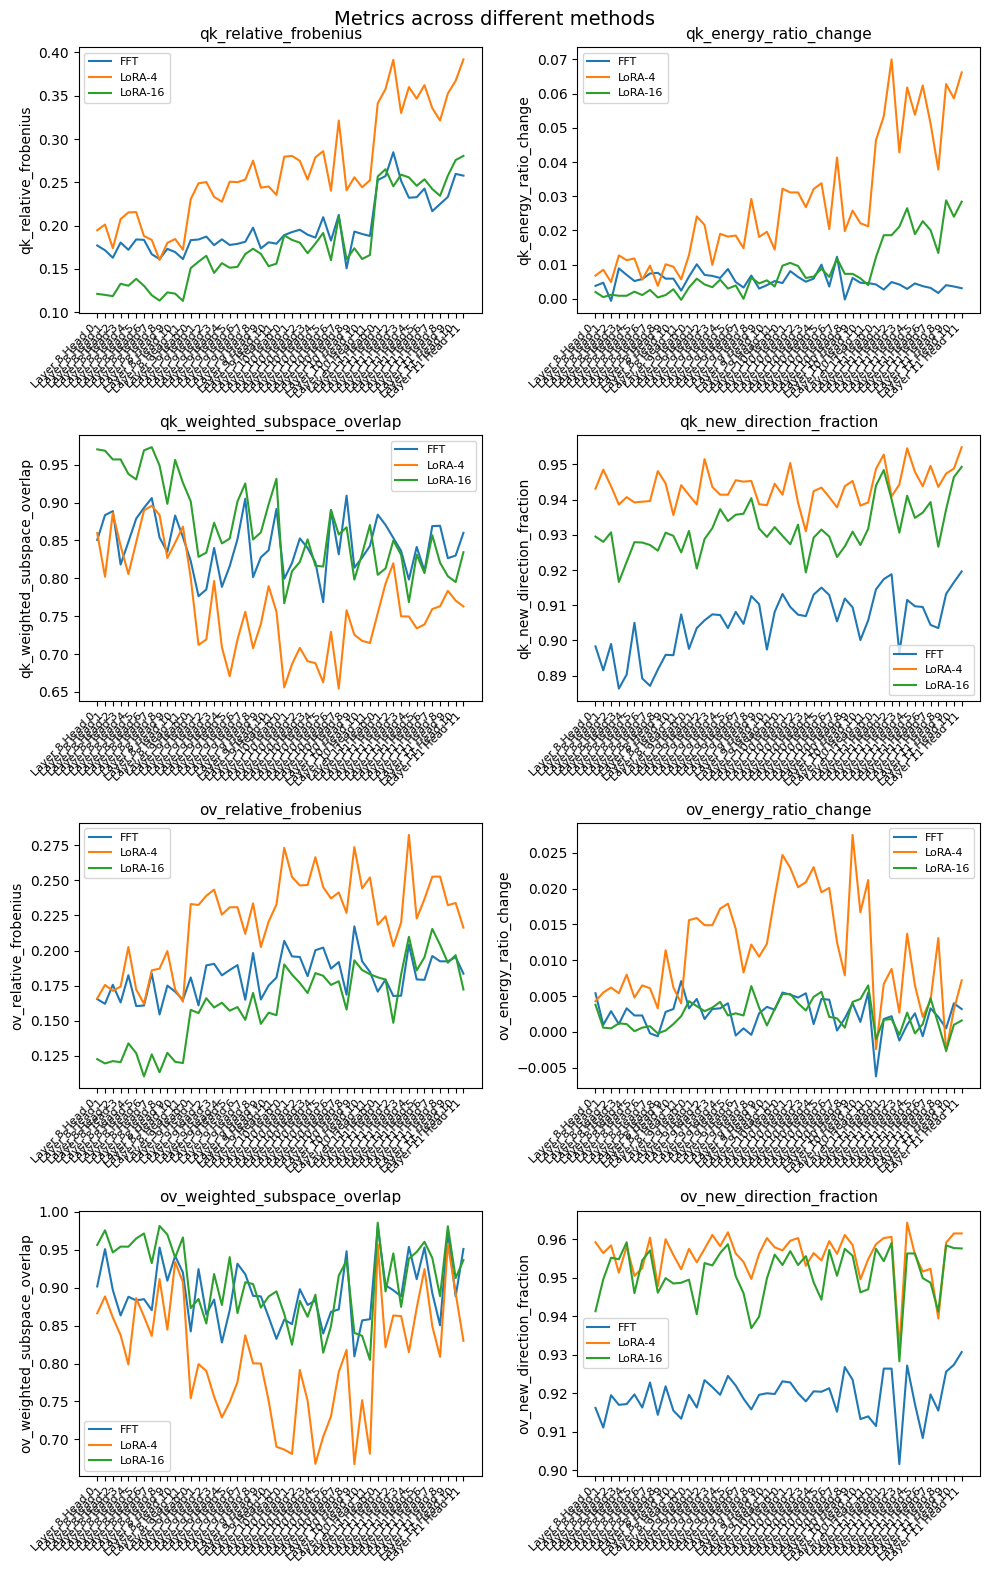

In [86]:
sun_val = True
fft = load_all(json_paths_fft+JSON_PATHS_org, sun=sun_val)
lora4 = load_all(json_paths_lora4+JSON_PATHS_org, sun=sun_val)
lora16 = load_all(json_paths_lora16+JSON_PATHS_org, sun=sun_val)
my_keys = list(fft.keys())[0:48]
# metric_list = [REPRESENTATION_CHANGE[i] for i in [0, 1, 2, 6]]
metric_list = WEIGHT_CHANGE_filtered

plot_lala(metric_list, my_keys, fft, lora4, lora16)

In [25]:
pth = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_fft.json"
changes_fft = json.load(open(pth))

# unique categories in changes_fft[keys]['category']
unique_categories = set()
for key in changes_fft:
    unique_categories.add(changes_fft[key]['category'])

unique_categories

{'Became useless', 'Changed function', 'Mixed', 'Same function', 'Specialized'}

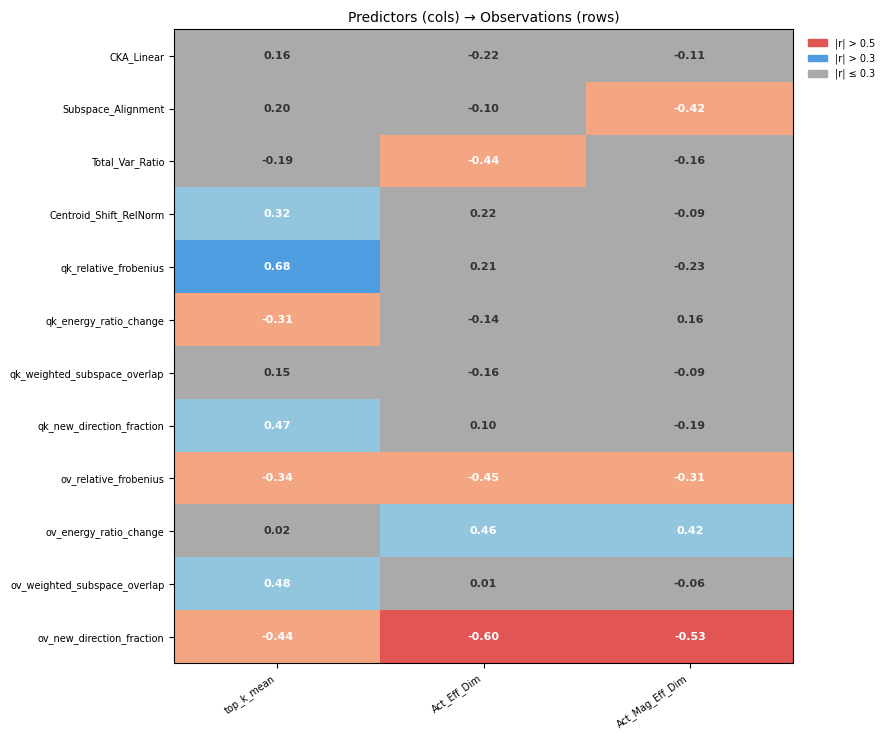

,predictor,observation,r,p_value,abs_r
0,top_k_mean,qk_relative_frobenius,0.6786,0.00027,0.6786
1,Act_Eff_Dim,ov_new_direction_fraction,-0.5954,0.00214,0.5954
2,Act_Mag_Eff_Dim,ov_new_direction_fraction,-0.5251,0.00841,0.5251
3,top_k_mean,ov_weighted_subspace_overlap,0.4751,0.01897,0.4751
4,top_k_mean,qk_new_direction_fraction,0.4705,0.02033,0.4705
5,Act_Eff_Dim,ov_energy_ratio_change,0.4627,0.02280,0.4627
6,Act_Eff_Dim,ov_relative_frobenius,-0.4542,0.02576,0.4542
7,top_k_mean,ov_new_direction_fraction,-0.4366,0.03290,0.4366
8,Act_Eff_Dim,Total_Var_Ratio,-0.4352,0.03355,0.4352
9,Act_Mag_Eff_Dim,Subspace_Alignment,-0.4208,0.04058,0.4208


In [23]:
df = cross_correlations(
    predictors=["top_k_mean", "Act_Eff_Dim", "Act_Mag_Eff_Dim"],
    # predictors=REPRESENTATION_CHANGE,
    observations=[name for name in REPRESENTATION_CHANGE_filtered]+WEIGHT_CHANGE_filtered,
    key_indices=list(range(24, 48)),
    data=fft,
    plot=False,
    plot_grid=True,
    top_n=20,
)

df

### discrete

In [58]:
# z = [changes_fft[key] for key in changes_fft if changes_fft[key]['ambiguous'] == False]
# len(z)

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score


def build_dataframe(metrics_json, category_json, metric_keys, exclude_category="Mixed", mode="fft"):
    rows = []
    for head, cat_info in category_json.items():
        # category = cat_info.get("category")
        category = cat_info[mode].get("category")
        if category == exclude_category or head not in metrics_json:
            continue
        row = {"head": head, "category": category}
        for k in metric_keys:
            row[k] = metrics_json[head].get(k, np.nan)
        rows.append(row)

    df = pd.DataFrame(rows).dropna(subset=metric_keys, how="all")
    df[metric_keys] = df[metric_keys].apply(pd.to_numeric, errors="coerce")
    present_metrics = [m for m in metric_keys if m in df.columns and df[m].notna().sum() > 3]

    print(f"Heads loaded: {len(df)}  |  Categories: {sorted(df['category'].unique())}")
    print(f"Metrics available: {present_metrics}\n")
    return df, present_metrics


def _eta_squared_kruskal(df, metric, group_col="category"):
    groups = [grp[metric].dropna().values for _, grp in df.groupby(group_col)]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return np.nan, np.nan, np.nan
    stat, p = kruskal(*groups)
    n = sum(len(g) for g in groups)
    k = len(groups)
    return stat, p, max((stat - k + 1) / (n - k), 0)


def compute_individual_stats(df, present_metrics):
    results = [
        {"metric": m, **dict(zip(["H_stat", "p_value", "eta_squared"], _eta_squared_kruskal(df, m)))}
        for m in present_metrics
    ]
    individual_df = pd.DataFrame(results).sort_values("eta_squared", ascending=False).reset_index(drop=True)

    print("=" * 65)
    print("INDIVIDUAL METRIC CORRELATION WITH CATEGORY (Kruskal-Wallis)")
    print("=" * 65)
    print(individual_df.to_string(index=False, float_format="{:.4f}".format))
    print("\neta_squared guide:  0.01 = small  |  0.06 = medium  |  0.14 = large\n")
    return individual_df


def plot_individual(df, individual_df, n_top=5):
    top_metrics = individual_df.head(n_top)["metric"].tolist()
    cat_order = sorted(df["category"].unique())
    palette = sns.color_palette("Set2", n_colors=df["category"].nunique())

    fig, axes = plt.subplots(
        1 + len(top_metrics), 1,
        figsize=(12, 4 + 3 * len(top_metrics)),
        gridspec_kw={"height_ratios": [2] + [1] * len(top_metrics)},
    )
    fig.suptitle("Metric–Category Correlation Analysis", fontsize=14, fontweight="bold")

    ax = axes[0]
    colors = ["#d62728" if p < 0.05 else "#aec7e8" for p in individual_df["p_value"]]
    ax.barh(individual_df["metric"][::-1], individual_df["eta_squared"][::-1], color=colors[::-1])
    ax.axvline(0.01, ls="--", color="gray", lw=0.8, label="small (0.01)")
    ax.axvline(0.06, ls="--", color="orange", lw=0.8, label="medium (0.06)")
    ax.axvline(0.14, ls="--", color="red", lw=0.8, label="large (0.14)")
    ax.set_xlabel("η² (eta-squared)")
    ax.set_title("Effect Size per Metric (red = p < 0.05)")
    ax.legend(fontsize=8, loc="lower right")

    for i, metric in enumerate(top_metrics):
        ax = axes[i + 1]
        sns.boxplot(data=df, x="category", y=metric, order=cat_order, palette=palette, ax=ax, width=0.5, fliersize=3)
        row = individual_df[individual_df["metric"] == metric].iloc[0]
        ax.set_title(f"{metric}   (η²={row.eta_squared:.3f}, p={row.p_value:.4f})", fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=15, labelsize=8)

    plt.tight_layout()
    plt.show()


def compute_pairwise(df, present_metrics):
    pair_results = []
    for m1, m2 in combinations(present_metrics, 2):
        tmp = df.copy()
        tmp["_inter"] = df[m1].fillna(0) * df[m2].fillna(0)
        stat, p, eta2 = _eta_squared_kruskal(tmp, "_inter")
        pair_results.append({"m1": m1, "m2": m2, "H_stat": stat, "p_value": p, "eta_squared": eta2})

    pairs_df = pd.DataFrame(pair_results).sort_values("eta_squared", ascending=False).reset_index(drop=True)

    print("=" * 65)
    print("PAIRWISE INTERACTION SCAN  (interaction = m1 × m2,  Kruskal-Wallis)")
    print("=" * 65)
    print(pairs_df.head(15).to_string(index=False, float_format="{:.4f}".format))
    print()
    return pairs_df


def compute_rf_importances(df, present_metrics, pairs_df, n_top_pairs=20):
    le = LabelEncoder()
    y = le.fit_transform(df["category"])
    X_base = df[present_metrics].fillna(df[present_metrics].median())

    top_pairs = pairs_df.head(n_top_pairs)
    inter_cols = {
        f"{r.m1} × {r.m2}": (df[r.m1].fillna(0) * df[r.m2].fillna(0)).values
        for _, r in top_pairs.iterrows()
    }
    X_full = pd.concat([X_base.reset_index(drop=True), pd.DataFrame(inter_cols)], axis=1)

    rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=42)
    rf.fit(X_full, y)
    cv_scores = cross_val_score(rf, X_full, y, cv=min(5, len(df) // 3), scoring="f1_macro")

    imp_df = (
        pd.DataFrame({"feature": X_full.columns, "importance": rf.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print("=" * 65)
    print(f"RANDOM FOREST  (CV f1_macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f})")
    print("=" * 65)
    print(imp_df.head(20).to_string(index=False, float_format="{:.4f}".format))
    print()
    return imp_df


def plot_rf_importance(imp_df, n_top=15):
    top = imp_df.head(n_top)
    is_interaction = top["feature"].str.contains(" × ")
    bar_colors = ["#e377c2" if v else "#1f77b4" for v in is_interaction]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.barh(top["feature"][::-1], top["importance"][::-1], color=bar_colors[::-1])
    ax.set_xlabel("RF feature importance")
    ax.set_title("Feature Importances (blue = raw metric  |  pink = interaction)")
    ax.legend(handles=[
        mpatches.Patch(color="#1f77b4", label="raw metric"),
        mpatches.Patch(color="#e377c2", label="interaction term"),
    ], fontsize=8)
    plt.tight_layout()
    plt.show()


# def plot_scatter_grid(df, imp_df, pairs_df, n_top_pairs=4):
#     cat_order = sorted(df["category"].unique())
#     cat_colors = dict(zip(cat_order, sns.color_palette("Set2", len(cat_order))))
#     top_inter_pairs = pairs_df.head(n_top_pairs)[["m1", "m2"]].values.tolist()

#     n = len(top_inter_pairs)
#     fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
#     if n == 1:
#         axes = [axes]

#     for ax, (m1, m2) in zip(axes, top_inter_pairs):
#         for cat in cat_order:
#             mask = df["category"] == cat
#             ax.scatter(df.loc[mask, m1], df.loc[mask, m2],
#                        label=cat, color=cat_colors[cat], alpha=0.75, s=50, edgecolors="k", lw=0.3)
#         ax.set_xlabel(m1, fontsize=8)
#         ax.set_ylabel(m2, fontsize=8)
#         ax.set_title(f"{m1}\n× {m2}", fontsize=8)

#     axes[-1].legend(fontsize=7, loc="best")
#     fig.suptitle("Top Pairwise Metric Interactions (coloured by category)", fontsize=11)
#     plt.tight_layout()
#     plt.show()

def plot_scatter_grid(df, imp_df, pairs_df, n_top_pairs=4):
    cat_order = sorted(df["category"].unique())
    cat_colors = dict(zip(cat_order, sns.color_palette("Set2", len(cat_order))))
    top_inter_pairs = pairs_df.head(n_top_pairs)[["m1", "m2"]].values.tolist()

    n = len(top_inter_pairs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, (m1, m2) in zip(axes, top_inter_pairs):
        for cat in cat_order:
            mask = df["category"] == cat
            ax.scatter(df.loc[mask, m1], df.loc[mask, m2],
                       label=cat, color=cat_colors[cat], alpha=0.75, s=50, edgecolors="k", lw=0.3)
            mx, my = df.loc[mask, m1].mean(), df.loc[mask, m2].mean()
            ax.scatter(mx, my, marker="*", s=300, color=cat_colors[cat], edgecolors="k", lw=0.8, zorder=5)
        ax.set_xlabel(m1, fontsize=8)
        ax.set_ylabel(m2, fontsize=8)
        ax.set_title(f"{m1}\n× {m2}", fontsize=8)

    axes[-1].legend(fontsize=7, loc="best")
    fig.suptitle("Top Pairwise Metric Interactions (coloured by category)", fontsize=11)
    plt.tight_layout()
    plt.show()



def plot_eta_heatmap(individual_df, pairs_df, present_metrics):
    eta_matrix = pd.DataFrame(np.nan, index=present_metrics, columns=present_metrics)
    for _, row in pairs_df.iterrows():
        eta_matrix.loc[row.m1, row.m2] = row.eta_squared
        eta_matrix.loc[row.m2, row.m1] = row.eta_squared
    for _, row in individual_df.iterrows():
        if row.metric in eta_matrix.index:
            eta_matrix.loc[row.metric, row.metric] = row.eta_squared

    mask = np.triu(np.ones_like(eta_matrix, dtype=bool), k=1)
    n = len(present_metrics)
    fig, ax = plt.subplots(figsize=(max(8, n), max(7, n - 1)))
    sns.heatmap(eta_matrix, mask=mask, annot=True, fmt=".3f",
                cmap="YlOrRd", linewidths=0.4, ax=ax,
                cbar_kws={"label": "η² (eta-squared)"})
    ax.set_title("Pairwise Interaction η² Heatmap\n(diagonal = individual metric effect size)", fontsize=11)
    plt.tight_layout()
    plt.show()


In [19]:
# heads = []
# rels = []
# modes = []
# old_rel = []

# old_rel2 = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_org_clip.json"))

# for head, thing in  CATEGORY_JSON.items():
#     for mode, cat in thing.items():
#         if cat['category'] == 'Ignored' and mode == "lp":
#             heads.append(head)
#             rels.append(cat['rank_mean'])
#             modes.append(mode)
#             old_rel.append(old_rel2[head]['rank_mean'])

# sorted_indices = sorted(range(len(rels)), key=lambda i: rels[i], reverse=False)

# print(len(heads), len(rels), len(modes))

# for i in sorted_indices:
#     print(f"{heads[i]}  |  {modes[i]}  |  {rels[i]:.4f} |  {old_rel[i]:.4f}")

In [ ]:
import json
JSON_PATHS_org = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_org_clip.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/head_spec_metrics.json",
]

json_paths_fft = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/change_metrics_fft.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/act_change_metrics_fft.json",
]

json_paths_lora4 = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/act_change_metrics_lora4.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/change_metrics_lora4.json"
]

json_paths_lora16 = [
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/act_change_metrics_lora16.json",
    "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/change_metrics_lora16.json"
]

sun_val = None
fft = load_all(json_paths_fft+JSON_PATHS_org, dataset=sun_val)
lora4 = load_all(json_paths_lora4+JSON_PATHS_org, dataset=sun_val)
lora16 = load_all(json_paths_lora16+JSON_PATHS_org, dataset=sun_val)

Heads loaded: 48  |  Categories: ['Ignored', 'different_function', 'same_function', 'specialized']
Metrics available: ['top_k_mean', 'Act_Eff_Dim']

INDIVIDUAL METRIC CORRELATION WITH CATEGORY (Kruskal-Wallis)
     metric  H_stat  p_value  eta_squared
 top_k_mean 31.6814   0.0000       0.6518
Act_Eff_Dim 16.7828   0.0008       0.3132

eta_squared guide:  0.01 = small  |  0.06 = medium  |  0.14 = large

PAIRWISE INTERACTION SCAN  (interaction = m1 × m2,  Kruskal-Wallis)
        m1          m2  H_stat  p_value  eta_squared
top_k_mean Act_Eff_Dim 33.2705   0.0000       0.6880

RANDOM FOREST  (CV f1_macro: 0.555 ± 0.122)
                 feature  importance
              top_k_mean      0.3672
top_k_mean × Act_Eff_Dim      0.3664
             Act_Eff_Dim      0.2664



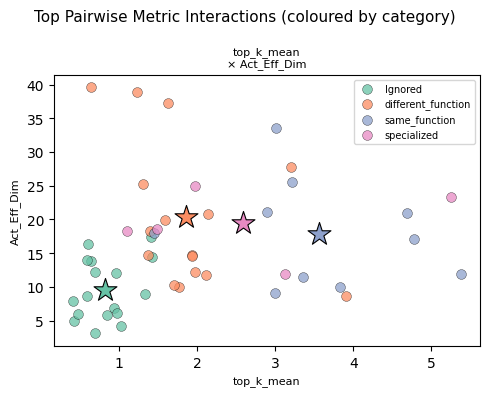

In [24]:
# ── Inputs ────────────────────────────────────────────────────────────────────
METRICS_JSON      = lora16
CATEGORY_JSON     = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_merged.json"))
# METRIC_KEYS       = ["qk_weighted_subspace_overlap", "ov_weighted_subspace_overlap", "Subspace_Alignment"]
METRIC_KEYS = ["top_k_mean", "Act_Eff_Dim"]
EXCLUDE_CATEGORY  = "Mixed"

# ── Run ───────────────────────────────────────────────────────────────────────
df, present_metrics = build_dataframe(METRICS_JSON, CATEGORY_JSON, METRIC_KEYS, EXCLUDE_CATEGORY, mode="lora16")

individual_df = compute_individual_stats(df, present_metrics)
# plot_individual(df, individual_df, n_top=5)

pairs_df = compute_pairwise(df, present_metrics)
imp_df   = compute_rf_importances(df, present_metrics, pairs_df)
# plot_rf_importance(imp_df)
plot_scatter_grid(df, imp_df, pairs_df, n_top_pairs=4)
# plot_eta_heatmap(individual_df, pairs_df, present_metrics)

Heads loaded: 47  |  Categories: ['Became useless', 'Changed function', 'Same function', 'Specialized']
Metrics available: ['rank_mean', 'Act_Mag_Eff_Dim']

INDIVIDUAL METRIC CORRELATION WITH CATEGORY (Kruskal-Wallis)
         metric  H_stat  p_value  eta_squared
      rank_mean 29.3558   0.0000       0.6129
Act_Mag_Eff_Dim  5.3601   0.1472       0.0549

eta_squared guide:  0.01 = small  |  0.06 = medium  |  0.14 = large

PAIRWISE INTERACTION SCAN  (interaction = m1 × m2,  Kruskal-Wallis)
       m1              m2  H_stat  p_value  eta_squared
rank_mean Act_Mag_Eff_Dim 20.0569   0.0002       0.3967

RANDOM FOREST  (CV f1_macro: 0.508 ± 0.106)
                    feature  importance
                  rank_mean      0.4599
rank_mean × Act_Mag_Eff_Dim      0.3003
            Act_Mag_Eff_Dim      0.2397



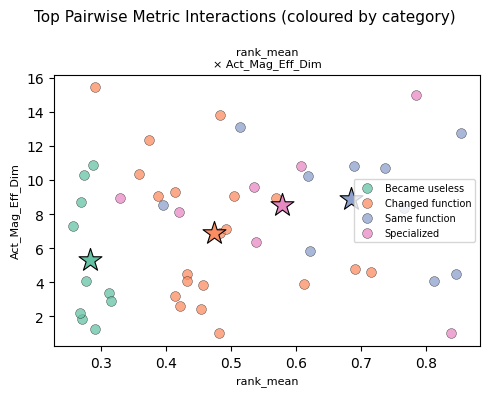

In [65]:
# ── Inputs ────────────────────────────────────────────────────────────────────
METRICS_JSON      = fft
CATEGORY_JSON     = changes_fft
# METRIC_KEYS       = ["qk_weighted_subspace_overlap", "ov_weighted_subspace_overlap", "Subspace_Alignment"]
METRIC_KEYS = ["rank_mean", "Act_Mag_Eff_Dim"]
EXCLUDE_CATEGORY  = "Mixed"

# ── Run ───────────────────────────────────────────────────────────────────────
df, present_metrics = build_dataframe(METRICS_JSON, CATEGORY_JSON, METRIC_KEYS, EXCLUDE_CATEGORY)

individual_df = compute_individual_stats(df, present_metrics)
# plot_individual(df, individual_df, n_top=5)

pairs_df = compute_pairwise(df, present_metrics)
imp_df   = compute_rf_importances(df, present_metrics, pairs_df)
# plot_rf_importance(imp_df)
plot_scatter_grid(df, imp_df, pairs_df, n_top_pairs=4)
# plot_eta_heatmap(individual_df, pairs_df, present_metrics)

In [87]:
import re
import pandas as pd


def create_head_table(
    annotation_json,
    before_json,
    after_json,
    category,
    top_n=5,
    styled=True
):

    def natural_sort_key(text):
        nums = re.findall(r"\d+", text)
        return [int(x) for x in nums]

    def format_list(items):
        """Pretty multiline formatting."""
        return "<br>".join(f"• {x}" for x in items)

    rows = []

    selected_heads = [
        head
        for head, info in annotation_json.items()
        if info.get("category") == category
    ]

    selected_heads = sorted(selected_heads, key=natural_sort_key)

    for head in selected_heads:

        before = before_json.get(head, {})
        after = after_json.get(head, {})

        before_groups = list(
            before.get("top_groups", {}).keys()
        )[:top_n]

        before_texts = before.get("top_texts", [])[:top_n]

        after_groups = list(
            after.get("top_groups", {}).keys()
        )[:top_n]

        after_texts = after.get("top_texts", [])[:top_n]

        rows.append({
            "Head": head,
            "Before Groups": format_list(before_groups),
            "Before Texts": format_list(before_texts),
            "After Groups": format_list(after_groups),
            "After Texts": format_list(after_texts),
        })

    df = pd.DataFrame(rows)

    if not styled:
        return df

    # Nicer notebook rendering
    styled_df = (
        df.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left",
            "vertical-align": "top",
            "white-space": "pre-wrap",
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                    ("background-color", "#f5f5f5"),
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "10px"),
                    ("max-width", "300px"),
                ]
            }
        ])
    )

    return styled_df

annotations = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_fft.json"))
before_heads = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/group_text_org.json"))
after_heads = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/for_cld/group_text_fft.json"))
c1 = "Became useless"
c2 = "Changed function"
c3 = "Specialized"
c4 = "Same function"
df = create_head_table(
    annotation_json=annotations,
    before_json=before_heads,
    after_json=after_heads,
    category=c4
)

from IPython.display import display

display(df)

Head,Before Groups,Before Texts,After Groups,After Texts
Layer 9 Head 2,"• Patterns, Textures & Designs• Artistic Styles & Movements• Textures & Materials (Close-up)• Macro & Close-up Photography• Graffiti & Street Art",• Intricate textile patterns• Unpredictable pattern• Woven textile design• Street art-inspired mural painting• Surreal digital collage,"• Animals• Dogs & Canines• Colors• Patterns, Textures & Designs• Reptiles & Amphibians",• Great_Pyrenees• clumber• Labrador_retriever• standard_poodle• Scottish_deerhound
Layer 9 Head 8,• Fashion & Clothing• Architecture & Buildings• Markets & Commerce• Historical & Antique• Urban & City Scenes,• Photograph taken in a fashion boutique• Photograph taken in a rustic barn• Photograph taken in a soda shop• Photograph taken in a cozy interior• cozy home interior,"• Architecture & Buildings• Household Objects & Furniture• Markets & Commerce• Music, Dance & Performance• Historical & Antique",• vault• grocery_store• theater_curtain• stage• seat_belt
Layer 10 Head 2,• Plants & Botanical• Headwear & Headgear• Fashion & Clothing• Professions & Occupations• Animals,• A turban• An image of a Welder• A bonnet• A hat• Flowers,• Fashion & Clothing• Headwear & Headgear• Weapons & Armor• Colors• Fruits,• cowboy_hat• feather_boa• bow_tie• bathing_cap• banana
Layer 10 Head 6,• Locations & Places• Cultural & Traditional• Colors• Vintage & Retro Aesthetics• Photography Techniques & Styles,• Photo taken in a museum• cultural exhibition• Vivid cultural exhibition• colorful exhibition• cozy coffee shop,• Architecture & Buildings• Markets & Commerce• Fashion & Clothing• Professions & Occupations• People & Portraits,• lab_coat• restaurant• bookshop• groom• shopping_cart
Layer 10 Head 10,• Mood & Atmosphere (Serene / Peaceful)• Water & Aquatic• Natural Landscapes• Natural Landforms & Geology• Marine & Aquatic Life,• Tranquil boating on a lake• Tranquil riverside• Tranquil riverside scene• peaceful garden pond• Tranquil riverbank scene,• Household Objects & Furniture• Water & Aquatic• Natural Landforms & Geology• Natural Landscapes• Sports & Athletics,• tub• sandbar• seashore• lakeside• bathtub
Layer 11 Head 3,• Professions & Occupations• Transportation & Vehicles• Water & Aquatic• Marine & Aquatic Life• Food & Cuisine,• An image of a Emergency Medical Technician (EMT)• An image of a Paramedic• An image of a Veterinarian• An image of a Veterinary Technician• Image of an ambulance,• Transportation & Vehicles• Medical & Scientific• Architecture & Buildings• Optical & Scientific Instruments• Kitchen & Cooking Equipment,• ambulance• stretcher• stethoscope• police_van• stove
Layer 11 Head 5,• Animals• Reptiles & Amphibians• Insects & Arachnids• Macro & Close-up Photography• Birds,• Photo of a reptile• detailed reptile close-up• A snake• Snapshot of a marsupial• Image with a seagull,"• Animals• Dogs & Canines• Reptiles & Amphibians• Insects & Arachnids• Patterns, Textures & Designs",• Chihuahua• Pekinese• cauliflower• wolf_spider• honeycomb
Layer 11 Head 6,• Locations & Places• Natural Landscapes• Natural Landforms & Geology• Sports & Athletics• Sky & Space,• Photo taken in the Alaskan mountains• Photo taken in Namib Desert• Photo taken in the Rub' al Khali (Empty Quarter)• Photo taken in Swiss Alps• an image of liechtenstein,• Natural Landforms & Geology• Natural Landscapes• Water & Aquatic• Mood & Atmosphere (Serene / Peaceful)• Food & Cuisine,• alp• lakeside• sandbar• acorn_squash• palace
Layer 11 Head 8,• Architecture & Buildings• Technology & Electronics• Fashion & Clothing• Containers & Vessels• Office & Stationery,• A laptop• cozy home library• Inviting home library• A bag• A wallet,• Household Objects & Furniture• Containers & Vessels• Textiles & Fabrics• Kitchen & Cooking Equipment• Office & Stationery,• tray• binder• doormat• carton• envelope
Layer 11 Head 10,• Colors• Fruits• Weather & Atmosphere• Cultural & Traditional• Black & White / Monochrome,• An image with cold green tones• Image with a green c

In [91]:
import re
import json
import pandas as pd


def create_head_table(
    annotation_json,
    before_json,
    after_json,
    top_n=5,
    show_texts=True,
    styled=True,
):
    """
    Create a table for all heads.

    Args:
        annotation_json: dict with category labels
        before_json: dict with original head info
        after_json: dict with adapted head info
        top_n: number of top groups/texts to display
        show_texts: whether to include text columns
        styled: return styled dataframe for notebook display
    """

    def natural_sort_key(text):
        nums = re.findall(r"\d+", text)
        return [int(x) for x in nums]

    # def format_list(items):
    #     """Pretty multiline formatting."""
    #     if not items:
    #         return ""
    #     return "<br>".join(f"• {x}" for x in items)
    def format_list(items, include_values=True):
        if not items:
            return ""

        if include_values:
            return "<br>".join(
                f"• {k} ({v:.1f})"
                for k, v in items
            )

        return "<br>".join(f"• {x}" for x in items)

    rows = []

    # union of all keys to avoid missing heads
    all_heads = sorted(
        set(annotation_json.keys())
        | set(before_json.keys())
        | set(after_json.keys()),
        key=natural_sort_key
    )

    for head in all_heads:

        annotation = annotation_json.get(head, {})
        before = before_json.get(head, {})
        after = after_json.get(head, {})

        category = annotation.get("category", "")

        before_groups = list(
            before.get("top_groups", {}).items()
        )[:top_n]

        after_groups = list(
            after.get("top_groups", {}).items()
        )[:top_n]

        row = {
            "Head": head,
            "Category": category,
            "Before Groups": format_list(before_groups),
            "After Groups": format_list(after_groups),
        }

        # Optional text columns
        if show_texts:
            before_texts = before.get(
                "top_texts", []
            )[:top_n]

            after_texts = after.get(
                "top_texts", []
            )[:top_n]

            row["Before Texts"] = format_list(before_texts)
            row["After Texts"] = format_list(after_texts)

        rows.append(row)

    df = pd.DataFrame(rows)

    if not styled:
        return df

    # Notebook-friendly styled rendering
    styled_df = (
        df.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left",
            "vertical-align": "top",
            "white-space": "pre-wrap",
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                    ("background-color", "#f5f5f5"),
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "10px"),
                    ("max-width", "300px"),
                ]
            }
        ])
    )

    return styled_df


df = create_head_table(
    annotation_json=annotations,
    before_json=before_heads,
    after_json=after_heads,
    top_n=5,
    show_texts=False,
)

display(df)

Head,Category,Before Groups,After Groups
Layer 8 Head 0,Changed function,"• Locations & Places (29.7)• Letters, Text & Writing (4.2)• Plants & Botanical (1.6)• Natural Landscapes (1.0)• Trees & Forests (0.8)",• Animals (424.3)• Dogs & Canines (99.9)• Marine & Aquatic Life (95.3)• Reptiles & Amphibians (80.5)• Birds (70.6)
Layer 8 Head 1,Became useless,"• Facial Expressions & Emotions (15.9)• Locations & Places (5.3)• Mood & Atmosphere (Serene / Peaceful) (1.5)• Spirals, Swirls & Vortexes (0.5)• Trees & Forests (0.4)",• Household Objects & Furniture (10.9)• Food & Cuisine (2.1)• Containers & Vessels (0.4)• Weather & Atmosphere (0.4)• Animals (0.4)
Layer 8 Head 2,Became useless,• Sky & Space (38.9)• Stars & Star-shaped (38.7)• Aerial & Bird's-Eye Views (1.8)• Natural Landscapes (0.8)• Body Parts (0.7),• Animals (103.4)• Colors (41.7)• Dogs & Canines (12.4)• Birds (5.8)• Architecture & Buildings (3.4)
Layer 8 Head 3,Became useless,"• Artistic Styles & Movements (294.2)• Fashion & Clothing (169.5)• Letters, Text & Writing (153.1)• Vintage & Retro Aesthetics (125.6)• Patterns, Textures & Designs (122.4)",• Musical Instruments (115.9)• Containers & Vessels (83.6)• Jewelry & Accessories (83.6)• Household Objects & Furniture (27.4)• Technology & Electronics (21.6)
Layer 8 Head 4,Became useless,"• Facial Expressions & Emotions (399.6)• Letters, Text & Writing (171.3)• People & Portraits (107.3)• Professions & Occupations (39.4)• Mood & Atmosphere (Dramatic / Mysterious) (20.9)",• Animals (46.3)• Fashion & Clothing (29.8)• Dogs & Canines (23.1)• Textiles & Fabrics (15.8)• People & Portraits (13.0)
Layer 8 Head 5,Changed function,• Vintage & Retro Aesthetics (191.6)• Caricatures & Illustrations (106.4)• Artistic Styles & Movements (66.7)• Macro & Close-up Photography (63.2)• Textures & Materials (Close-up) (56.5),"• Kitchen & Cooking Equipment (172.9)• Technology & Electronics (103.8)• Containers & Vessels (45.5)• Letters, Text & Writing (40.7)• Textiles & Fabrics (26.0)"
Layer 8 Head 6,Became useless,• Locations & Places (283.8)• Black & White / Monochrome (127.9)• Colors (118.9)• Professions & Occupations (6.4)• Technology & Electronics (5.5),• Body Parts (45.5)• Technology & Electronics (30.7)• Optical & Scientific Instruments (11.8)• Animals (5.2)• Vintage & Retro Aesthetics (3.6)
Layer 8 Head 7,Changed function,"• Caricatures & Illustrations (90.1)• Historical & Antique (42.8)• Artistic Styles & Movements (41.9)• Fantasy, Magic & Surreal (40.4)• Futuristic & Science Fiction (9.6)",• Animals (928.6)• Dogs & Canines (610.9)• Reptiles & Amphibians (73.6)• Primates (46.8)• Colors (28.0)
Layer 8 Head 8,Specialized,"• Fantasy, Magic & Surreal (105.7)• Letters, Text & Writing (83.9)• Vintage & Retro Aesthetics (54.1)• Mood & Atmosphere (Serene / Peaceful) (52.7)• Graffiti & Street Art (32.5)",• Containers & Vessels (116.4)• Architecture & Buildings (77.8)• Animals (73.9)• Markets & Commerce (64.2)• Sports & Athletics (50.6)
Layer 8 Head 9,Changed function,• Night & Darkness (95.7)• Vintage & Retro Aesthetics (52.8)• Lighting & Light Effects (42.6)• Urban & City Scenes (36.0)• Photography Techniques & Styles (29.8),"• Animals (204.9)• Toys, Games & Recreation (187.2)• Household Objects & Furniture (98.8)• Structures & Barriers (95.7)• Birds (88.7)"


### useless

Early: top-10 → 9 QK, 1 OV
Late: top-10 → 0 QK, 10 OV

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Predictor group : ('Act_Mag_Eff_Dim', 'ov_spectral_distance')
  Target group    : ('rank_mean', 'top_k_mean')
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── Method 1 · Derived Feature Correlations ──


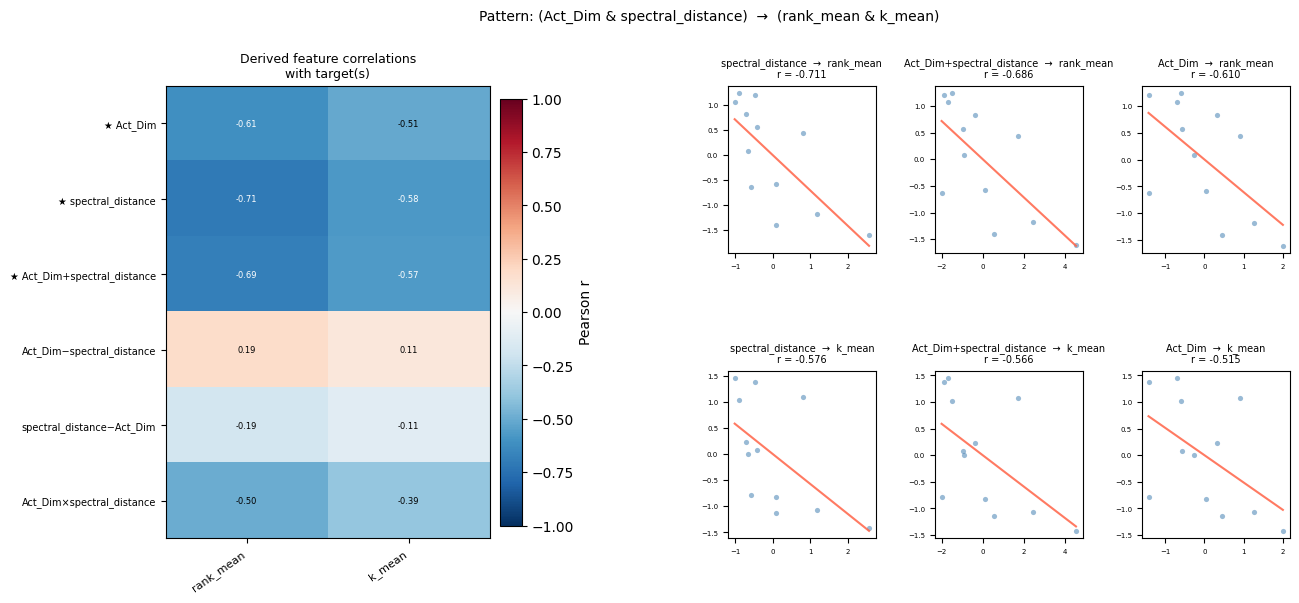

                  feature    target       r
        spectral_distance rank_mean -0.7108
Act_Dim+spectral_distance rank_mean -0.6861
                  Act_Dim rank_mean -0.6103
        spectral_distance    k_mean -0.5756
Act_Dim+spectral_distance    k_mean -0.5664
                  Act_Dim    k_mean -0.5149
Act_Dim×spectral_distance rank_mean -0.4972
Act_Dim×spectral_distance    k_mean -0.3887

── Method 2 · Multiple Regression (with interactions) ──


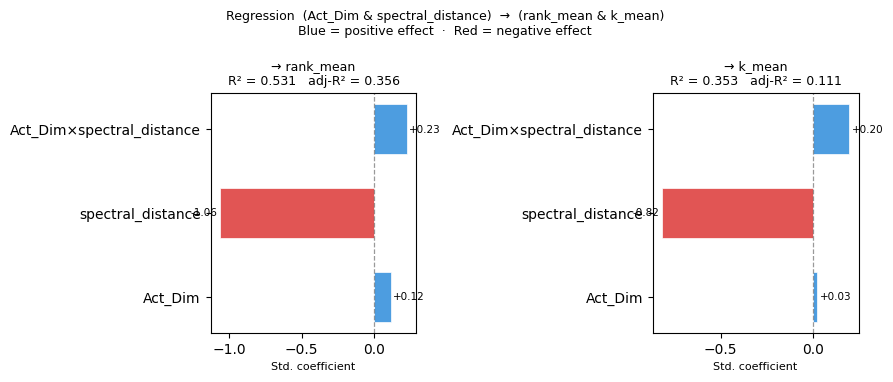

In [35]:
# 1. Show the QK vs OV split across layers
early = list(range(0, 24))   # first 2 layers
late  = list(range(36, 48))  # last layer

df_early = cross_correlations(
    predictors=HEAD_SPECIFICITY,
    observations=WEIGHT_CHANGE,
    key_indices=early,
)

df_late = cross_correlations(
    predictors=HEAD_SPECIFICITY,
    observations=WEIGHT_CHANGE,
    key_indices=late,
)

# compare: what fraction of top-10 hits are qk_ vs ov_?
for label, d in [("Early", df_early), ("Late", df_late)]:
    top = d.head(10)
    n_qk = top["observation"].str.startswith("qk_").sum()
    n_ov = top["observation"].str.startswith("ov_").sum()
    print(f"{label}: top-10 → {n_qk} QK, {n_ov} OV")


# 2. Does OV specialization in late layers → new task usefulness?
plot_group_correlations(
    metric_groups=[
        ("Act_Mag_Eff_Dim", "ov_spectral_distance"),
        ("rank_mean", "top_k_mean"),
    ],
    key_indices=late,
    methods=("derived", "regression"),
)

In [ ]:
def cross_group_scan(spec_list, task_list, change_list, key_indices=None, data=None, top_n=20):
    """
    For every (spec_metric, task_metric) pair, build derived features
    (individual, sum, diff, product) and correlate each with every change metric.
    Returns top_n results sorted by |r|.
    """
    if data is None:
        data = all_data
    heads = list(data.keys())
    if key_indices is not None:
        heads = [heads[i] for i in key_indices]

    def _z(arr):
        s = arr.std()
        return (arr - arr.mean()) / s if s > 0 else arr * 0

    # precompute and z-score everything
    zs = {}
    for m in set(spec_list + task_list + change_list):
        zs[m] = _z(np.array([data[h][m] for h in heads], dtype=float))

    rows = []
    for sm in spec_list:
        for tm in task_list:
            # derived features from one spec + one task metric
            feats = {
                sm:            zs[sm],
                tm:            zs[tm],
                f"{sm}+{tm}":  zs[sm] + zs[tm],
                f"{sm}−{tm}":  zs[sm] - zs[tm],
                f"{tm}−{sm}":  zs[tm] - zs[sm],
                f"{sm}×{tm}":  zs[sm] * zs[tm],
            }
            for fname, fvals in feats.items():
                for cm in change_list:
                    r, p = stats.pearsonr(fvals, zs[cm])
                    rows.append({
                        "spec_metric": sm,
                        "task_metric": tm,
                        "feature": fname,
                        "change_metric": cm,
                        "r": round(r, 4),
                        "p_value": round(p, 6),
                        "abs_r": round(abs(r), 4),
                    })

    df = (pd.DataFrame(rows)
            .sort_values("abs_r", ascending=False)
            .reset_index(drop=True))

    # deduplicate: individual metrics (sm alone, tm alone) appear in every pair
    # keep only the first (highest) occurrence
    seen = set()
    keep = []
    for i, row in df.iterrows():
        key = (row["feature"], row["change_metric"])
        if key not in seen:
            seen.add(key)
            keep.append(i)
    df = df.loc[keep].reset_index(drop=True)

    return df.head(top_n)



In [ ]:
weight_change_relevant = ['qk_relative_frobenius',
 'qk_energy_ratio_change',
 'qk_spectral_distance',
 'qk_mean_cos_angle',
 'qk_weighted_subspace_overlap',
 'qk_new_direction_fraction',
 'qk_within_subspace_fraction',
 'ov_relative_frobenius',
 'ov_sv_correlation',
 'ov_energy_ratio_change',
 'ov_spectral_distance',
 'ov_mean_cos_angle',
 'ov_weighted_subspace_overlap',
 'ov_effective_rank_change',
 'ov_new_direction_fraction',
 'ov_within_subspace_fraction']

['qk_relative_frobenius',
 'qk_sv_correlation',
 'qk_energy_ratio_change',
 'qk_spectral_distance',
 'qk_mean_cos_angle',
 'qk_weighted_subspace_overlap',
 'qk_effective_rank_change',
 'qk_new_direction_fraction',
 'qk_within_subspace_fraction',
 'ov_relative_frobenius',
 'ov_sv_correlation',
 'ov_energy_ratio_change',
 'ov_spectral_distance',
 'ov_mean_cos_angle',
 'ov_weighted_subspace_overlap',
 'ov_effective_rank_change',
 'ov_new_direction_fraction',
 'ov_within_subspace_fraction']

In [44]:
df_top = cross_group_scan(
    spec_list=HEAD_SPECIFICITY,
    task_list=['rank_mean', 'top_k_mean'],
    change_list=[x for x in WEIGHT_CHANGE if x.startswith("qk_")],
    key_indices=list(range(24, 48)),  # late layers
    top_n=20,
)
print(df_top.to_string(index=False))

       spec_metric task_metric                   feature                change_metric       r  p_value  abs_r
      Text_Eff_Dim  top_k_mean   Text_Eff_Dim×top_k_mean qk_weighted_subspace_overlap -0.7060 0.000116 0.7060
       Act_Eff_Dim   rank_mean     Act_Eff_Dim×rank_mean            qk_sv_correlation  0.6456 0.000657 0.6456
      Text_Eff_Dim   rank_mean    Text_Eff_Dim×rank_mean qk_weighted_subspace_overlap -0.6389 0.000777 0.6389
   Act_Mag_Eff_Dim   rank_mean Act_Mag_Eff_Dim×rank_mean       qk_energy_ratio_change -0.6309 0.000947 0.6309
   Act_Mag_Eff_Dim   rank_mean Act_Mag_Eff_Dim×rank_mean         qk_spectral_distance -0.6283 0.001009 0.6283
      Text_Eff_Dim  top_k_mean   Text_Eff_Dim×top_k_mean            qk_mean_cos_angle -0.6212 0.001197 0.6212
   Act_Mag_Eff_Dim   rank_mean Act_Mag_Eff_Dim×rank_mean        qk_relative_frobenius -0.6210 0.001202 0.6210
      Text_Eff_Dim  top_k_mean                top_k_mean    qk_new_direction_fraction -0.6199 0.001234 0.6199
   Act_Mag